# Benchmark Raw GEx
Benchmark using as baseline raw GEx

# 0. Load Data

In [1]:
"""Load Data
Structure:
    1. Imports, Variables, Functions
    2. Load Data
"""

# 1. Imports, Variables, Functions
# imports
import pandas as pd, numpy as np, os, sys
import anndata as ad
import logging
from typing import *
import pickle
import matplotlib.pyplot as plt
import seaborn as sns
import json
from sklearn.metrics import (
    roc_auc_score,
    roc_curve,
    auc,
    precision_recall_curve,
    average_precision_score,
)
from sklearn.metrics import confusion_matrix, classification_report
import sys
sys.path.append(os.path.join("..", ".."))
from src.utils import utils as ut
from src.utils import viz as vz
from src.utils import io 
logging.basicConfig(level=logging.INFO)

# variables
run_dir = os.path.join("..","..","outputs","run-25-09-03-01") # A 
output_dir = os.path.join(run_dir, "outputs")


if not os.path.exists(output_dir):
    os.makedirs(output_dir)

# functions

# 2. Load Data
(
    # split,
    predictions_test,
    labels_test,
    results_test,
    all_outputs_test,
    predictions_valid,
    labels_valid,
    results_valid,
    all_outputs_valid,
    predictions_train,
    labels_train,
    results_train,
    all_outputs_train,
    adata_orig,
    id2type,
    train_indices,
    valid_indices,
) = io.load_run_output(run_dir)

# load json

with open(os.path.join(run_dir, "parameters.json"), "r") as f:
    parameters = json.load(f)

for k, v in parameters.items():
    print(f"{k}: {v}")

/aloy/home/ddalton/miniconda3/envs/scgpt/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loaded variable predictions_test
Loaded variable labels_test
Loaded variable results_test
Loaded variable all_outputs_test
Loaded variable predictions_valid
Loaded variable labels_valid
Loaded variable results_valid
Loaded variable all_outputs_valid
Loaded variable predictions_train
Loaded variable labels_train
Loaded variable results_train
Loaded variable all_outputs_train
Loaded variable adata_orig
Loaded variable id2type
Loaded variable train_indices
Loaded variable valid_indices
Nº of loaded variables 16
data_path: /aloy/home/ddalton/projects/scGPT_playground/data/pp_data-25-08-14-01/data.h5ad
max_seq_len: 3501
batch_size: 16
gene_presence_pct: 0.9
benchmark_data: False
split_type: stratified
val_split_type: random
n_splits: 10
n_tested_splits: 10
epochs: 50
gene_filtering: top_presence
sample_presence_pct: 0.3
MLM: False
CLS: False
CLS_multilabel: True
DAB: False
ADV: False
CCE: False
ecs_thres: 0.0
dab_weight: 0.0
use_fast_transformer: True
output_attentions: False
INPUT_BATCH_LA

In [2]:
split_idx = 0

# load all adata
adata_test =  ad.read_h5ad(
    os.path.join(run_dir, f"adata_test_{split_idx+1}.h5ad"), backed="r"
)
adata_test.obs.reset_index(drop=True, inplace=True)  
adata_valid =  ad.read_h5ad(
    os.path.join(run_dir, f"adata_valid_{split_idx+1}.h5ad"), backed="r"
)
adata_valid.obs.reset_index(drop=True, inplace=True)  
adata_train =  ad.read_h5ad(
    os.path.join(run_dir, f"adata_train_{split_idx+1}.h5ad"), backed="r"
)
adata_train.obs.reset_index(drop=True, inplace=True)  

## 0.2 Load DO Pairs

In [3]:
"""0.2 Load Disease Ontology Pairs
Load pairs of related and unrelated diseases from the Disease Ontology.
Structure:
    1. Imports, Variables, Functions
    2. Load Disease Pairs

"""
# 1. Imports, Variables, Functions
# imports


# variables

# functions


# 2. Load Disease Pairs

# Get disease IDs
d_ids = list(adata_train.obs["doid_id"].unique())

# load Disease Ontology Lin Similarity amongst pairs!
do_df_ic = ut.load_df_do_pairs()
print(f"Loaded universe of disease pairs: {do_df_ic.shape[0]}") 

# Load IC based similarity 
do_graph = ut.load_do_graph()
doid_to_term = {
    node: data["name"] for node, data in do_graph.nodes(data=True) if "name" in data
}

# get top 1% & 5% of values
ic_thr = np.quantile(do_df_ic["lin"].values, 0.95)
print(f"IC Threshold: {ic_thr:.3f}\tNº of pairss {len(do_df_ic.query('lin>@ic_thr'))}")

ic_thr_99 = np.quantile(do_df_ic["lin"].values, 0.99)
print(f"IC Threshold 99%: {ic_thr_99:.3f}\tNº of pairs {len(do_df_ic.query('lin>@ic_thr_99'))}")

# Filter pairs
do_df_ic_query = do_df_ic.query("do1 in @d_ids and do2 in @d_ids")
print("Nº of pairs in dataset:", do_df_ic_query.shape)

do_df_ic_query = do_df_ic.query(f"do1 in @d_ids and do2 in @d_ids and lin > {ic_thr}")
print("Nº of significant pairs in dataset (top 5% IC):", do_df_ic_query.shape)

do_df_ic_query_99 = do_df_ic.query(f"do1 in @d_ids and do2 in @d_ids and lin > {ic_thr_99}")
print("Nº of significant pairs in dataset (top 1% IC):", do_df_ic_query_99.shape)

do_df_negative_ic = do_df_ic.query(f"do1 in @d_ids and do2 in @d_ids and lin <= {ic_thr}")
print("Nº of negative pairs in dataset (outside 5%):", do_df_negative_ic.shape)

Loaded universe of disease pairs: 70442515
IC Threshold: 0.396	Nº of pairss 3518554
IC Threshold 99%: 0.543	Nº of pairs 704215
Nº of pairs in dataset: (8515, 8)
Nº of significant pairs in dataset (top 5% IC): (1015, 8)
Nº of significant pairs in dataset (top 1% IC): (382, 8)
Nº of negative pairs in dataset (outside 5%): (7500, 8)


# 1. Compute Similarity Matrixes

In [4]:
import pickle

path_pkl = os.path.join("/aloy/home/ddalton/projects/disease_signatures", "data", "DiSignAtlas", "signatures.pkl")
print(f"Loading signatures from file {path_pkl}")
signatures = pickle.load(open(path_pkl, "rb"))

Loading signatures from file /aloy/home/ddalton/projects/disease_signatures/data/DiSignAtlas/signatures.pkl


In [23]:
""" Define Sparsity & Matrix Dimensions

Structure:
    1. Import, Variables and Functions
    2. Get the most common gene ids
    3. Get the dsaids with the most common gene ids
    4. Create the data matrix
"""

# Imports, Variables and Functions
# imports

from collections import Counter

# variabels
sparsity = "LS"
sparsity_perc_sign_thr = {"LS": 0.8878, "HS": 0.25}
sparsity_perc_genes_thr = {"LS": 0.95, "HS": 0.5}
assert sparsity in ["LS", "HS"], "Err Sparsity not recognized"


# functions
def get_diff_dsaids(dsaids, dsaids_human):
    """Get human dataset ids which are different
    Arguments:
        - dsaids_human (list): dsaids of interest
        - dsaids (list): dsaids which are human
    Returns:
        - dsaids _diff_subsample (list): same nº as dsaids of interest,
        but different ones
    """
    import random

    N = len(dsaids)
    dsaids_diff = list(set(dsaids_human) - set(dsaids))
    dsaids_diff_subsample = random.sample(
        dsaids_diff,
        k=N,
    )
    logging.info(f"Sampled {len(dsaids_diff_subsample)} random different dsaids")
    return dsaids_diff_subsample


# imports
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# variables
metric_evaluated = "Log2FC"

d_default_value = {
    "PValue": 0.0,
    "AdjPValue": 1.0,
    "Log2FC": 0.0,
    "ReAdjPValue": 0.0,
    "iLINCS.100": 0.0,
    "iLINCS.200": 0.0,
    "iLINCS.all": 0.0,
    "iLINCS.ReAdj": 0.0,
    "Ranking.AdjPValue": 0.0,
    "Ranking.Log2FC": 0.0,
    "Significant.Log2FC": 0.0,
    "Significant.Log2FC.ReAdj": 0.0,
    "Filtered.Log2FC": 0.0,
}

variance_thr = 0.0
de_genes_thr = 30

assert metric_evaluated in [
    "PValue",
    "AdjPValue",
    "Log2FC",
    "ReAdjPValue",
    "iLINCS.100",
    "iLINCS.200",
    "iLINCS.all",
    "iLINCS.ReAdj",
    "Ranking.AdjPValue",
    "Ranking.Log2FC",
    "Significant.Log2FC",
    "Filtered.Log2FC",
    "Significant.Log2FC.ReAdj",
], "Err metric not found"


# functions
def get_human_entrez_protein_coding_ids():
    """Get Human Entrez IDs
    Returns:
        list: list of human entrez ids
    """
    data_path = os.path.join("/aloy/home/ddalton/projects/disease_signatures", "data", "ncbi_gene_info", "gene_info")
    df = pd.read_csv(data_path, sep="\t", usecols=["#tax_id", "GeneID", "type_of_gene"])
    df_human = df[(df["#tax_id"] == 9606) & (df["type_of_gene"] == "protein-coding")]
    logging.info(f"Nº of Human protein coding genes: {len(df_human)}")
    return df_human["GeneID"].to_list()


def filter_information(reference, labels, values):
    """Filter information by reference
    Args:
        - reference (list): list of reference ids
        - labels (list): list of labe{sparsity}
        - values (list): list of values
    Returns:
        - labels (np.array): np.array of labels
        - values (np.array): np.array of values
    """
    reference = np.array(reference)
    labels = np.array(labels)
    values = np.array(values)
    mask = np.isin(labels, reference)
    return labels[mask], values[mask]


def sort_values(reference, labels, values, default_value=np.nan):
    """Sort values by reference"""

    values = np.array(values)
    d = dict(zip(labels, values))
    return [d.get(k, default_value) for k in reference]


def adjust_p_values(reference, labels, values, method="fdr_bh"):
    values = np.array(values)
    d = dict(zip(labels, values))

    # common labels between reference and labels
    common_labels = list(set(reference).intersection(set(labels)))

    # get values
    values = [d[k] for k in common_labels]

    if method == "fdr_bh":
        # adjust p-values
        adjusted_values = stats.false_discovery_control(values)

    # possible other methods (?)

    return common_labels, adjusted_values


def compute_signed_significance(p_values, log2fcs):
    """
    Calculate signed significance for each gene in the signature.
    Args:
    - dsaid: str

    Returns:
    - signed_significance: list of tupples
    - d_signed_significance: list of tupples
    """
    p_values = np.array(p_values)
    log2fcs = np.array(log2fcs)

    assert len(p_values) == len(log2fcs), "Err p_values and log2fcs not same length"
    signed_significance = list()
    for p_value, logfc in zip(p_values, log2fcs):
        # P Value should neve be 0
        if p_value == 0:
            p_value = min(p_values[p_values != 0])
        # chek if p_value is nan
        if not np.isnan(p_value):
            sign = np.sign(logfc)
            ss = sign * (-np.log10(p_value))
            signed_significance.append(ss)
        if np.isnan(p_value):
            raise ValueError("Log2FC is nan")
    return np.array(signed_significance)


def compute_extreme_signed_significance(signed_significance, genes, k=100):
    """
    Compute Extreme Signed Significance for top & bottom k ss genes, rest
    are assigned value of 0.

    Arguments:
    - signed_significance (np.array): list of signed significance

    - genes (np.array): list of gene ids

    - k: int()
        Top/Bottom k genes.

    Returns:
    - genes: list of gene ids
    - extreme_signed_significance: list of tupples
        List of gene ids and signed significance
    """
    # check if there are nans in the signed significance
    signed_significance_no_nan = signed_significance[~np.isnan(signed_significance)]
    signed_significance_nan = signed_significance[np.isnan(signed_significance)]

    genes_no_nan = genes[~np.isnan(signed_significance)]
    genes_nan = genes[np.isnan(signed_significance)]

    # Sort the signed_significance_no_nan in ascending order and get sorted indices
    sorted_indices = np.argsort(signed_significance_no_nan)

    # Apply sorting to both signed_significance_no_nan and genes_no_nan
    sorted_signed_significance_no_nan = signed_significance_no_nan[sorted_indices]
    sorted_genes_no_nan = genes_no_nan[sorted_indices]

    # Initialize a mask for all values as False (indicating all will be set to 0)
    mask = np.zeros(sorted_signed_significance_no_nan.shape, dtype=bool)

    # if there are 0s in the top or bottom 100 then they will be still 0's
    # after the mask

    if k:
        # Set True for the top 100 (smallest) and bottom 100 (largest) values in ascending order
        mask[:k] = True  # Smallest values
        mask[-k:] = True  # Largest values before NaNs

        # Apply the mask, setting values not in the top or bottom 100 to 0
        sorted_signed_significance_no_nan[~mask] = 0

    # Concatenate with NaN parts
    final_signed_significance = np.concatenate(
        [sorted_signed_significance_no_nan, signed_significance_nan]
    )
    final_genes = np.concatenate([sorted_genes_no_nan, genes_nan])
    return final_genes, final_signed_significance


def compute_ranking_log2fc(values, n, threshold=0.5):
    """Compute ranking
    Arguments:
        - values (numpy): array of values
        - n (int): nº of top values
    Returns:
        - ranking (numpy): array of ranking

    """
    # initialize ranking values
    ranking = np.zeros(len(values))

    # get sorted indexes
    sorted_indexes = np.argsort(values)

    # assign values to n top values
    for counter, i in enumerate(sorted_indexes[-n:]):
        if values[i] > threshold:
            # from 1 to n
            ranking[i] = 1 + counter

    # assign values to n bottom values
    for counter, i in enumerate(sorted_indexes[:n]):
        if values[i] < -threshold:
            # from -n to -1
            ranking[i] = -n + counter

    return ranking


def compute_ranking_log2fc(values, n, threshold=0.5):
    """Compute ranking
    Arguments:
        - values (numpy): array of values
        - n (int): nº of top values
    Returns:
        - ranking (numpy): array of ranking

    """
    # initialize ranking values
    ranking = np.zeros(len(values))

    # get sorted indexes
    sorted_indexes = np.argsort(values)

    # assign values to n top values
    for counter, i in enumerate(sorted_indexes[-n:]):
        if values[i] > threshold:
            # from 1 to n
            ranking[i] = 1 + counter

    # assign values to n bottom values
    for counter, i in enumerate(sorted_indexes[:n]):
        if values[i] < -threshold:
            # from -n to -1
            ranking[i] = -n + counter

    return ranking


def compute_ranking_adj_pvalue(values, n, threshold=0.05):
    """Compute ranking
    Arguments:
        - values (numpy): array of values
        - n (int): nº of top values
    Returns:
        - ranking (numpy): array of ranking

    """
    # initialize ranking values
    ranking = np.zeros(len(values))

    # get sorted indexes
    sorted_indexes = np.argsort(values)

    # assign values to n bottom values
    for counter, i in enumerate(sorted_indexes[:n]):
        if values[i] < threshold:
            # from -n to -1
            ranking[i] = n - counter

    return ranking


def get_significant_log2fc(
    log2fc, adj_p_values, thr_log2fc=0, thr_adj_p_values=0.05, normalize=False
):
    """Get significant log2fc
    Arguments:
        - log2fc (list): list of log2fc
        - adj_p_values (list): list of adj_p_values
        - thr_log2fc (float): threshold for log2fc
        - thr_adj_p_values (float): threshold for adj_p_values
    Returns:
        - significant_log2fc (list): list of significant log2fc
    """
    if normalize:
        # to do
        pass
    else:
        significant_log2fc = list()
        for i in range(len(log2fc)):
            if (abs(log2fc[i]) >= thr_log2fc) and (adj_p_values[i] <= thr_adj_p_values):
                significant_log2fc.append(log2fc[i])
            else:
                significant_log2fc.append(np.nan)
        return np.array(significant_log2fc)


def get_filtered_log2fc(log2fc, winsorize_limit=0.001):
    """Get filtered log2fc
    Returns:
        - log2fc (list): list of log2fc
    """
    # imports
    from scipy.stats.mstats import winsorize
    import numpy as np

    # using scikit-learn's MinMaxScaler
    from sklearn.preprocessing import MinMaxScaler

    # Winsorizing data
    log2fc_winsorized = winsorize(np.array(log2fc), limits=winsorize_limit).data

    # Convert masked array to numpy array
    log2fc_winsorized = np.array(log2fc_winsorized.data)
    # Create a MinMaxScaler object with range [-1, 1]
    scaler = MinMaxScaler(feature_range=(-1, 1))

    # Normalize the data
    # Reshape data for the scaler
    log2fc_normalized = scaler.fit_transform(log2fc_winsorized.reshape(-1, 1))
    return log2fc_normalized.flatten()


# load human protein-coding gene ids
human_entrez_protein_coding_ids = get_human_entrez_protein_coding_ids()

# Map all human protein-coding genes to the signatures
all_gene_ids = [s for signature in signatures for s in set(signature[2])]
counts_all_gene_ids = Counter(all_gene_ids)

counts_all_gene_ids_protein_coding = dict()
for k, v in counts_all_gene_ids.items():
    if k in human_entrez_protein_coding_ids:
        counts_all_gene_ids_protein_coding[k] = v

# Get the sorted counts of protein-coding genes
sorted_counts_all_gene_ids_protein_coding = [
    (k, v)
    for k, v in sorted(
        counts_all_gene_ids_protein_coding.items(),
        key=lambda item: item[1],
        reverse=True,
    )
]

# Get depending on the sparsity the most common gene ids of interest
most_common_gene_ids = [
    k
    for k, v in counts_all_gene_ids_protein_coding.items()
    if v >= int(sparsity_perc_sign_thr.get(sparsity) * len(signatures))
]

logging.info(
    f"{sparsity} Most common gene ids: {len(most_common_gene_ids)} for {sparsity} >= {int(sparsity_perc_sign_thr.get(sparsity) * len(signatures))} / {len(signatures)}"
)

# sort gene ids
most_common_gene_ids = sorted(most_common_gene_ids)


INFO:root:Nº of Human protein coding genes: 20608
INFO:root:LS Most common gene ids: 7383 for LS >= 6215 / 7001


In [24]:
len(most_common_gene_ids)

7383

In [25]:
dsaids_common_gene_ids = [
    s[0]
    for s in signatures
    if len(set(s[2]).intersection(most_common_gene_ids))
    >= int(len(most_common_gene_ids) * sparsity_perc_genes_thr.get(sparsity))
]

In [26]:
len(dsaids_common_gene_ids)

5877

In [27]:
from tqdm import tqdm
# 3. Get the dsaids with the most common gene ids
# dsaids w/ gene ids
# loop through signatures and get dsaids with an intersection against
# the most common gene ids above or equal to a threshold
dsaids_common_gene_ids = [
    s[0]
    for s in signatures
    if len(set(s[2]).intersection(most_common_gene_ids))
    >= int(len(most_common_gene_ids) * sparsity_perc_genes_thr.get(sparsity))
]

# dsaids_filtered = [d for d in dsaids_common_gene_ids if d in dsaids_with_doid]

dsaids_train = list(set(adata_train.obs["dsaid"]) & set(dsaids_common_gene_ids))
dsaids_test = list(set(adata_test.obs["dsaid"]) & set(dsaids_common_gene_ids))
dsaids_filtered = dsaids_train + dsaids_test

logging.info(
    f"Nº of dsaids w/ common gene ids {sparsity}: {len(dsaids_common_gene_ids)}"
)

logging.info(
    f"Nº of dsaids w/ common gene ids & mesh tree terms {len(dsaids_filtered)}"
)

# 4. Create the data matrix
# create data matrix
data_matrix = np.zeros((len(dsaids_filtered), len(most_common_gene_ids)))

logging.info(f"Data matrix {sparsity} shape: {data_matrix.shape}")



# matrix w/ common gene ids
zero_variance_dsaids_all_genes = list()
zero_variance_dsaids_specific_genes = list()
zero_significant_dsaids = list()
dsaids_matrix = list()
rows_filled = 0
if metric_evaluated.startswith("iLINCS"):
    n_ess = list()


signature_ids = [s[0] for s in signatures]
for i, dsaid_specific in enumerate(tqdm(dsaids_filtered)):
    if (dsaid_specific == "DSA04660") or (dsaid_specific == "DSA09547"):
        continue
    # get index of dsaid
    idx = signature_ids.index(dsaid_specific)

    # retrieve signature
    signature = signatures[idx]

    # quality check
    assert signatures[idx][0] == dsaid_specific, "Err not matching dsaid"

    # get values
    gene_ids = signature[2]
    p_values = signature[3]
    adj_p_values = signature[4]
    log2fc = signature[5]

    # check variance for all genes
    if (np.var(adj_p_values) == variance_thr) or (np.var(log2fc) == variance_thr):
        zero_variance_dsaids_all_genes.append(dsaid_specific)
        continue

    # sort values
    if metric_evaluated == "AdjPValue":
        sorted_values = sort_values(
            reference=most_common_gene_ids,
            labels=gene_ids,
            values=adj_p_values,
        )
    elif metric_evaluated == "Log2FC":
        sorted_values = sort_values(
            reference=most_common_gene_ids,
            labels=gene_ids,
            values=log2fc,
        )

    elif metric_evaluated == "PValue":
        sorted_values = sort_values(
            reference=most_common_gene_ids,
            labels=gene_ids,
            values=p_values,
        )

    elif metric_evaluated == "ReAdjPValue":

        common_gene_ids, re_adj_p_values = adjust_p_values(
            reference=most_common_gene_ids, labels=gene_ids, values=p_values
        )

        sorted_values = sort_values(
            reference=most_common_gene_ids,
            labels=gene_ids,
            values=p_values,
        )

    elif metric_evaluated.startswith("iLINCS"):
        """Wer are computing the extreme signed significance for
        those genes of interest. Not for all genes. This is a decision
        which is arbitrary. Justification is that we are interested in
        the scope of genes of interest.
        """

        if metric_evaluated == "iLINCS.ReAdj":
            # re-adjust p-values
            common_gene_ids, re_adj_p_values = adjust_p_values(
                reference=most_common_gene_ids, labels=gene_ids, values=p_values
            )

            # order log2fc same order as adj_p_values
            d_log2fc = dict(zip(gene_ids, log2fc))
            ordered_log2fc = [d_log2fc.get(id) for id in common_gene_ids]

            # re-define variables for later
            log2fc = ordered_log2fc
            adj_p_values = re_adj_p_values
            gene_ids = common_gene_ids

        # filter adj_p_values
        filtered_gene_ids, filtered_adj_p_values = filter_information(
            reference=most_common_gene_ids, labels=gene_ids, values=adj_p_values
        )

        # filter log2fc
        filtered_gene_ids, filtered_log2fc = filter_information(
            reference=most_common_gene_ids, labels=gene_ids, values=log2fc
        )

        # compute signed significance
        signed_significance = compute_signed_significance(
            filtered_adj_p_values, filtered_log2fc
        )

        k_ilincs = (
            False
            if metric_evaluated == "iLINCS.all" or metric_evaluated == "iLINCS.ReAdj"
            else int(metric_evaluated.split(".")[1])
        )

        # compute extreme signed significance
        gene_ids_ess, ess = compute_extreme_signed_significance(
            signed_significance=signed_significance,
            genes=filtered_gene_ids,
            k=k_ilincs,
        )

        # sort values
        sorted_values = sort_values(
            reference=most_common_gene_ids,
            labels=gene_ids_ess,
            values=ess,
        )

    if metric_evaluated == "Ranking.AdjPValue":

        # compute ranking
        ranking = compute_ranking_adj_pvalue(adj_p_values, n=200, threshold=0.05)

        sorted_values = sort_values(
            reference=most_common_gene_ids,
            labels=gene_ids,
            values=ranking,
        )

    if metric_evaluated == "Ranking.Log2FC":

        # compute ranking
        ranking = compute_ranking_log2fc(log2fc, n=100, threshold=0.5)

        sorted_values = sort_values(
            reference=most_common_gene_ids,
            labels=gene_ids,
            values=ranking,
        )

    if metric_evaluated == "Significant.Log2FC":

        # compute ranking
        significant_log2fc = get_significant_log2fc(
            log2fc, adj_p_values, thr_log2fc=0, thr_adj_p_values=0.05, normalize=False
        )

        if np.any(significant_log2fc) < -1:
            break

        sorted_values = sort_values(
            reference=most_common_gene_ids,
            labels=gene_ids,
            values=significant_log2fc,
        )

    if metric_evaluated == "Significant.Log2FC.ReAdj":
        common_gene_ids, re_adj_p_values = adjust_p_values(
            reference=most_common_gene_ids, labels=gene_ids, values=p_values
        )

        # order log2fc same order as adj_p_values
        d_log2fc = dict(zip(gene_ids, log2fc))
        ordered_log2fc = [d_log2fc.get(id) for id in common_gene_ids]

        # get significant log2fc
        significant_log2fc = get_significant_log2fc(
            ordered_log2fc,
            re_adj_p_values,
            thr_log2fc=0,
            thr_adj_p_values=0.05,
            normalize=False,
        )

        sorted_values = sort_values(
            reference=most_common_gene_ids,
            labels=common_gene_ids,
            values=significant_log2fc,
        )

    if metric_evaluated == "Filtered.Log2FC":
        # compute filtered log2fc
        filtered_log2fc = get_filtered_log2fc(log2fc, winsorize_limit=0.001)

        sorted_values = sort_values(
            reference=most_common_gene_ids,
            labels=gene_ids,
            values=filtered_log2fc,
        )

    # check variance for specific genes
    # check if there are significant genes here
    if len(np.array(sorted_values)[~np.isnan(sorted_values)]) == 0:
        zero_significant_dsaids.append(dsaid_specific)
        continue

    if np.var(np.array(sorted_values)[~np.isnan(sorted_values)]) == variance_thr:
        zero_variance_dsaids_specific_genes.append(dsaid_specific)

        continue

    # check nº of extreme signed significance genes
    if metric_evaluated.startswith("iLINCS"):
        ess_no_nan = ess[~np.isnan(ess)]
        if np.array(ess_no_nan, dtype="bool").sum() <= de_genes_thr:
            continue

    # fill rows with data
    for j, value in enumerate(sorted_values):
        data_matrix[rows_filled, j] = value

    # if it passes check ! !
    rows_filled += 1
    dsaids_matrix.append(dsaid_specific)





# remove rows not filled
data_matrix = data_matrix[:rows_filled, :]
logging.info(f"Data matrix {sparsity} shape: {data_matrix.shape}")


# report how many dsaids have zero variance
logging.info(
    f"{sparsity} Zero variance dsaids all genes: {len(zero_variance_dsaids_all_genes)}"
)
logging.info(
    f"{sparsity} Zero variance dsaids specific genes: {len(zero_variance_dsaids_specific_genes)}"
)

# check zero variance genes
count = 0
for j in range(data_matrix.shape[1]):
    if np.var(data_matrix[:, j]) == 0:
        count += 1
assert count == 0, "Err zero variance genes"

# check zero variance dsaids
count = 0
for i in range(data_matrix.shape[0]):
    if np.var(data_matrix[i]) == 0:
        count += 1
assert count == 0, "Err zero variance dsaids"

# check de genes in iLINCS processing
for row in range(data_matrix.shape[0]):
    if data_matrix[row, :].astype(bool).sum() <= de_genes_thr:
        raise ValueError(f"{sparsity} Err nº of DE genes <= {de_genes_thr}")

# mask where there are nans
nan_mask = np.isnan(data_matrix)

# assign nans default value
data_matrix[nan_mask] = d_default_value.get(metric_evaluated)

INFO:root:Nº of dsaids w/ common gene ids LS: 5877
INFO:root:Nº of dsaids w/ common gene ids & mesh tree terms 950
INFO:root:Data matrix LS shape: (950, 7383)
100%|██████████| 950/950 [00:03<00:00, 261.66it/s]
INFO:root:Data matrix LS shape: (950, 7383)
INFO:root:LS Zero variance dsaids all genes: 0
INFO:root:LS Zero variance dsaids specific genes: 0


In [28]:
from typing import *
from scipy.spatial.distance import cdist
import itertools
import obonet
import networkx as nx
import sys
sys.path.append(os.path.join("..", ".."))
from src.utils import utils as ut
from src.utils import viz as vz
import logging
import os

all_adatas = pd.concat([adata_train.obs, adata_test.obs, adata_valid.obs], axis=0)
all_adatas = all_adatas.query("do_id != 'Control'")
dsaid_2_doid = dict(
    zip(
        all_adatas["dsaid"],
        all_adatas["doid_id"],
    )
)
dsaid_2_dataset = dict(
    zip(
        all_adatas["dsaid"],
        all_adatas["dataset"],
    )
)


df_train = pd.DataFrame(
    {"dsaid": dsaids_train, "doid_id": [dsaid_2_doid.get(d) for d in dsaids_train], "do_id": [dsaid_2_doid.get(d) for d in dsaids_train], "dataset": [dsaid_2_dataset.get(d) for d in dsaids_train]}
)

df_test = pd.DataFrame(
    {"dsaid": dsaids_test, "doid_id": [dsaid_2_doid.get(d) for d in dsaids_test], "do_id": [dsaid_2_doid.get(d) for d in dsaids_test], "dataset": [dsaid_2_dataset.get(d) for d in dsaids_test]}
)


X_train = data_matrix[: len(dsaids_train), :]
X_test = data_matrix[len(dsaids_train) :, :]


c_matrix_train = 1 -  cdist(X_train, X_train, "correlation")
# c_matrix_train = 1 -  cdist(X_train, X_train, "correlation")


c_matrix_test_vs_train = 1 - cdist(X_test, X_train, "correlation")



In [29]:
c_matrix_train = 1 -  cdist(X_train, X_train, "correlation")

In [30]:
import random
from matplotlib.ticker import EngFormatter


def get_related_dis_sim(df_data, c_matrix, df_related, df_unrelated, labels, sample:int=None): 

    fmt = EngFormatter(places=1)
   
   # select datasets & do_ids
    do_ids = df_data["do_id"].values
    datasets = df_data["dataset"].values

    # get pairs    
    unrelated_pairs = list(df_unrelated["pair_sorted"].unique())
    unrelated_universe = vz.get_doid_idxs_pairs(unrelated_pairs, do_ids, return_weights=False)
    print(f"Nº of unrelated disease pairs: {len(unrelated_universe)}")
    
    c_all = list()
    w_all = list()
    l_all = list()
    _sample_sizes = list()
    for i, label_i in enumerate(labels):
        _df_related = df_related.query(f"shortest_path_length == {label_i}")
        print(f"[SP {label_i}] Nº of related disease pairs: {len(_df_related)}")

        # get related pairs
        related_idxs, _l_related = vz.get_doid_idxs_pairs(list(_df_related["pair_sorted"]), do_ids, datasets, return_weights=True)
        print(f"Nº of related disease pairs for {label_i}: {len(related_idxs)}")
        
        if len(related_idxs) == 0:
            continue

        # convert label to weights - all pairs add to 1
        _w_related = vz._convert_labels_to_weights(_l_related)

        if sample & (len(related_idxs) > sample):
            _sample_i = random.sample(range(len(related_idxs)), sample)
            related_idxs = related_idxs[_sample_i]
            _w_related = _w_related[_sample_i]

        # retrieve similarities
        _c_related = c_matrix[related_idxs[:, 0], related_idxs[:, 1]]

        # append values
        c_all.append(_c_related)
        w_all.append(_w_related)
        
        _sample_sizes.append(len(_c_related))

        # append labels
        l_all.append(f"{label_i} | {len(_df_related)} pairs | {fmt(len(_c_related))} comps",)


    # get sample of SAME DISEASE
    same_idxs, _l_same = vz.get_doid_idxs_single(do_ids, datasets, return_weights=True)
    _w_same = vz._convert_labels_to_weights(_l_same)
    _c_same = c_matrix[same_idxs[:, 0], same_idxs[:, 1]]
    c_all.append(_c_same)
    w_all.append(_w_same)
    l_all.append(f"Same Disease | {len(set(do_ids)-set(['Control']))} dis | {fmt(len(_c_same))} comps")

    # get sample of unrelated pairs
    print(_sample_sizes)
    _sample_i = random.sample(range(len(unrelated_universe)), max(_sample_sizes))
    _unrelated_sample = unrelated_universe[_sample_i]
    print(f"Nº of unrelated disease pairs: {len(_unrelated_sample)}")
    
    _s_unrelated = c_matrix[_unrelated_sample[:, 0], _unrelated_sample[:, 1]]
    _w_unrelated = np.ones(len(_s_unrelated))   # do not weight - they are random - no groupings
    c_all.append(_s_unrelated)
    w_all.append(_w_unrelated)
    l_all.append(f"Unrelated | {fmt(len(_s_unrelated))} comps")

    return c_all, w_all, l_all


In [31]:

def get_unrelated_pairs_split_2(df_qry, df_ref, c_matrix, df_unrelated, dsaid_2_dis:dict,sample_size:int=None, include_control:bool=False):

    fmt = EngFormatter(places=1)

    # select datasets & do_ids
    do_ids_qry = df_qry["do_id"].values
    datasets_qry = df_qry["dataset"].values

    do_ids_ref = df_ref["do_id"].values
    datasets_ref = df_ref["dataset"].values
    
    # get pairs
    unrelated_pairs = list(df_unrelated["pair_sorted"].unique())
    if include_control:
        # get pseudo label values
        do_ids_qry =  [dsaid_2_dis.get(d) for d in df_qry["dsaid"]]
        do_ids_ref =  [dsaid_2_dis.get(d) for d in df_ref["dsaid"]]


    unrelated_universe = vz.get_doid_idxs_pairs_split(unrelated_pairs, do_ids_qry, do_ids_ref, datasets_qry, datasets_ref, return_weights=False)
    
    if sample_size:    
        # get sample of unrelated pairs
        _idxs = random.sample(range(len(unrelated_universe)), sample_size)
        unrelated_universe = unrelated_universe[_idxs]

    s_unrelated = c_matrix[unrelated_universe[:, 0], unrelated_universe[:, 1]]
    w_unrelated = np.ones(len(s_unrelated))   # do not weight - they are random - no groupings
    l_unrelated = f"Unrelated | {fmt(len(s_unrelated))} comps"

    return s_unrelated, w_unrelated, l_unrelated


def get_related_dis_sim_splits(
    df_qry, df_ref, c_matrix, df_related, df_unrelated, labels, sample:int=None
):
    fmt = EngFormatter(places=1)
   
   # select datasets & do_ids
    do_ids_qry = df_qry["do_id"].values
    datasets_qry = df_qry["dataset"].values

    do_ids_ref = df_ref["do_id"].values
    datasets_ref = df_ref["dataset"].values

    # get pairs    
    unrelated_pairs = list(df_unrelated["pair_sorted"].unique())
    unrelated_universe = vz.get_doid_idxs_pairs_split(unrelated_pairs, do_ids_qry, do_ids_ref, datasets_qry, datasets_ref, return_weights=False)
    print(f"Nº of unrelated disease pairs: {len(unrelated_universe)}")
    
    c_all = list()
    w_all = list()
    l_all = list()
    _sample_sizes = list()
    for _, label_i in enumerate(labels):
        _df_related = df_related.query(f"shortest_path_length == {label_i}")
        print(f"[SP {label_i}] Nº of related disease pairs: {len(_df_related)}")

        # get related pairs
        related_idxs, _l_related = vz.get_doid_idxs_pairs_split(list(_df_related["pair_sorted"]), do_ids_qry, do_ids_ref, datasets_qry, datasets_ref, return_weights=True)
        print(f"Nº of related disease pairs for {label_i}: {len(related_idxs)}")

        # convert label to weights - all pairs add to 1
        _w_related = vz._convert_labels_to_weights(_l_related)

        if sample & (len(related_idxs) > sample):
            _sample_i = random.sample(range(len(related_idxs)), sample)
            related_idxs = related_idxs[_sample_i]
            _w_related = _w_related[_sample_i]

        # retrieve similarities
        _c_related = c_matrix[related_idxs[:, 0], related_idxs[:, 1]]

        # append values
        c_all.append(_c_related)
        w_all.append(_w_related)
        _sample_sizes.append(len(_c_related))

        # append labels
        l_all.append(f"{label_i} | {len(_df_related)} pairs | {fmt(len(_c_related))} comps",)


    # get sample of SAME DISEASE
    same_idxs, _l_same = vz.get_doid_idxs_single_set(do_ids_qry, do_ids_ref, datasets_qry, datasets_ref, return_weights=True)    
    _w_same = vz._convert_labels_to_weights(_l_same)
    if sample:
        _sample_i = random.sample(range(len(same_idxs)), sample)
        same_idxs = same_idxs[_sample_i]
        _w_same = _w_same[_sample_i]

    _c_same = c_matrix[same_idxs[:, 0], same_idxs[:, 1]]
    c_all.append(_c_same)
    w_all.append(_w_same)
    l_all.append(f"Same Disease | {len(set(do_ids_qry)-set(['Control']))} dis | {fmt(len(_c_same))} comps")

    # get sample of unrelated pairs
    _sample_i = random.sample(range(len(unrelated_universe)), max(_sample_sizes))
    _unrelated_sample = unrelated_universe[_sample_i]
    print(f"Nº of unrelated disease pairs: {len(_unrelated_sample)}")
    
    _s_unrelated = c_matrix[_unrelated_sample[:, 0], _unrelated_sample[:, 1]]
    _w_unrelated = np.ones(len(_s_unrelated))   # do not weight - they are random - no groupings
    c_all.append(_s_unrelated)
    w_all.append(_w_unrelated)
    l_all.append(f"Unrelated | {fmt(len(_s_unrelated))} comps")

    return c_all, w_all, l_all


100%|██████████| 7500/7500 [00:00<00:00, 58249.69it/s]


Nº of unrelated disease pairs: 238404
[SP '0.8-1'] Nº of related disease pairs: 58


100%|██████████| 58/58 [00:00<00:00, 44424.70it/s]


Nº of related disease pairs for '0.8-1': 1240
[SP '0.6-0.8'] Nº of related disease pairs: 169


100%|██████████| 169/169 [00:00<00:00, 37934.14it/s]


...

100%|██████████| 115/115 [00:00<00:00, 75190.17it/s]


Nº of unrelated disease pairs: 12083
121 diseases in dataset


7260it [00:05, 1239.64it/s]


238404 unrelated pairs found
10000
Selected 10000 unrelated pairs
Sampled pairs: 10000


100%|██████████| 7500/7500 [00:00<00:00, 66977.12it/s]


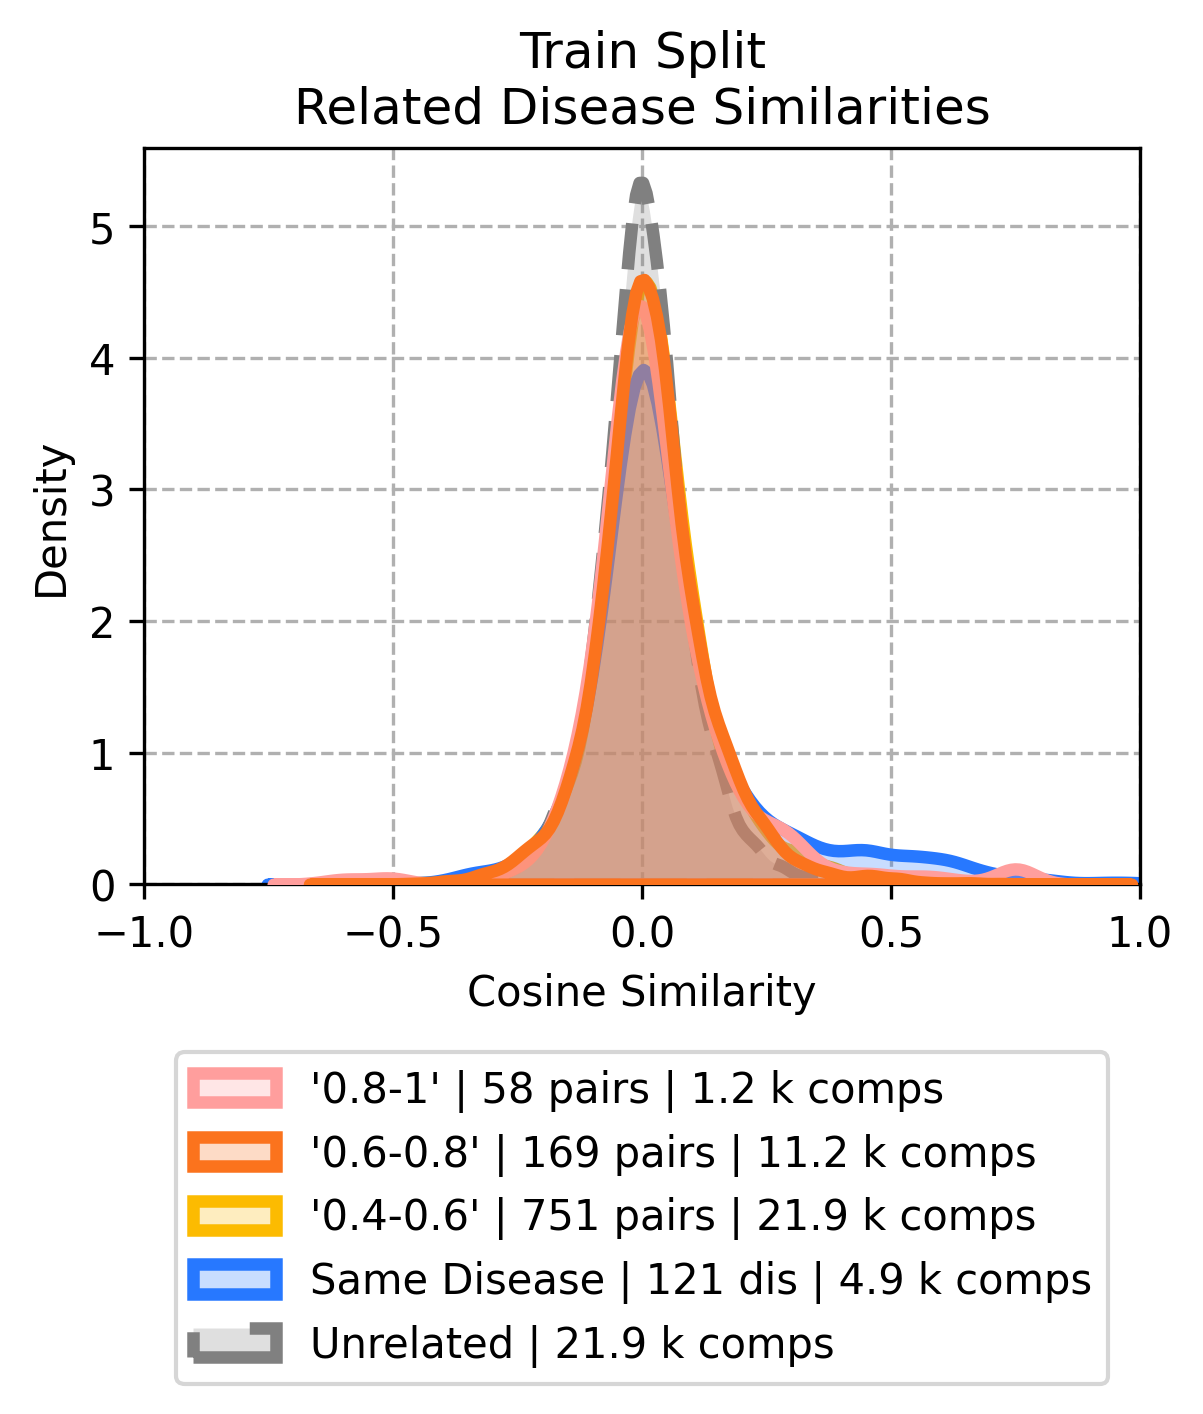

Nº of positive disease pairs: 1240
Nº of positive disease pairs: 1240
Nº of positive disease pairs: 11218
Nº of positive disease pairs: 10000
Nº of positive disease pairs: 21873
Nº of positive disease pairs: 10000
Nº of positive disease pairs: 4868
Nº of positive disease pairs: 4868


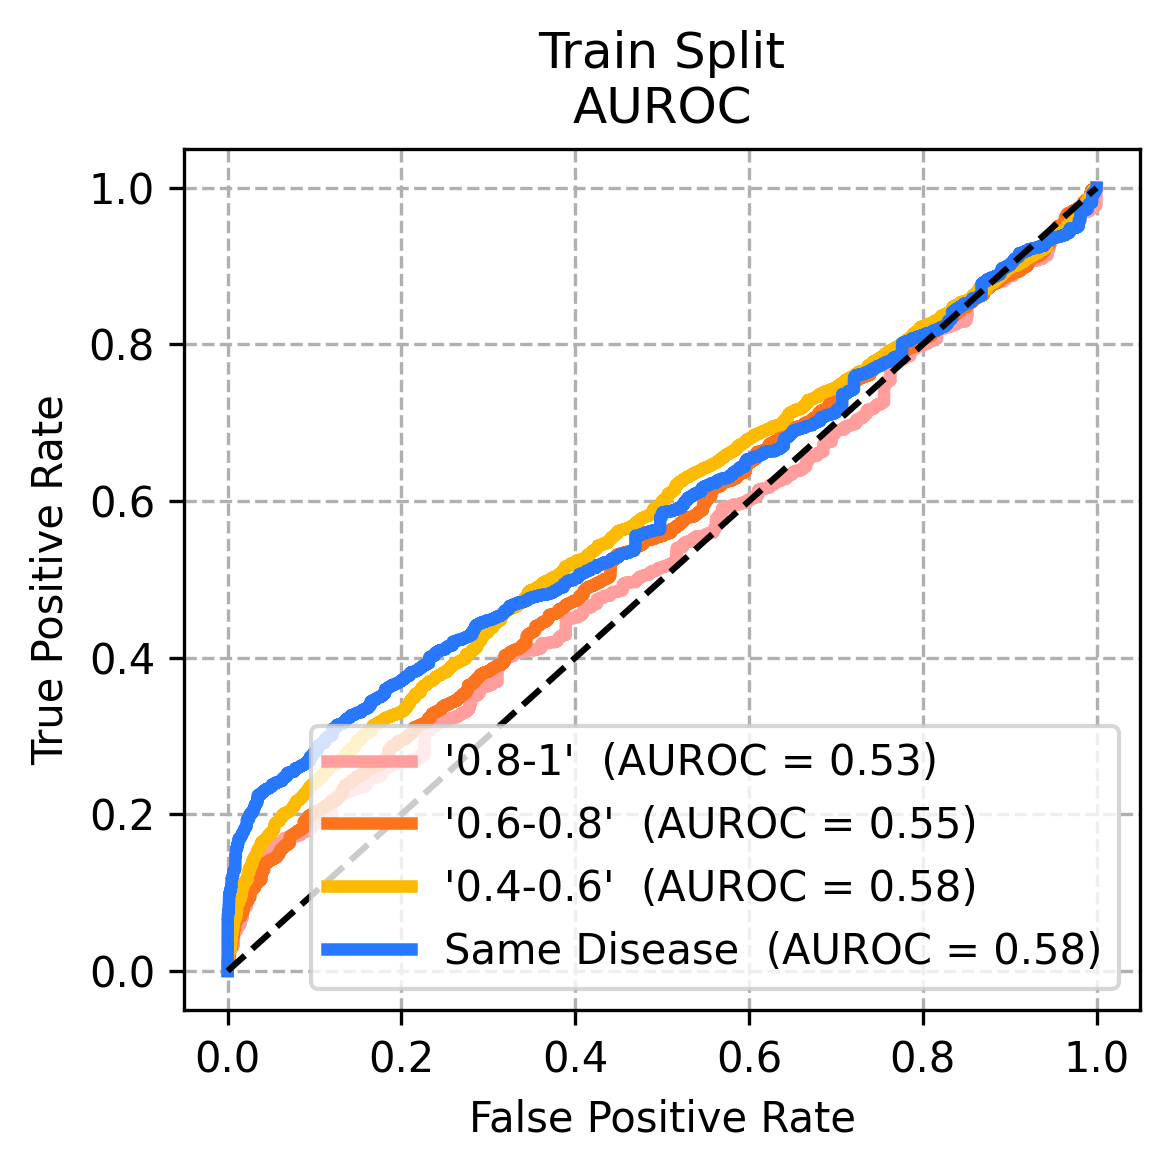

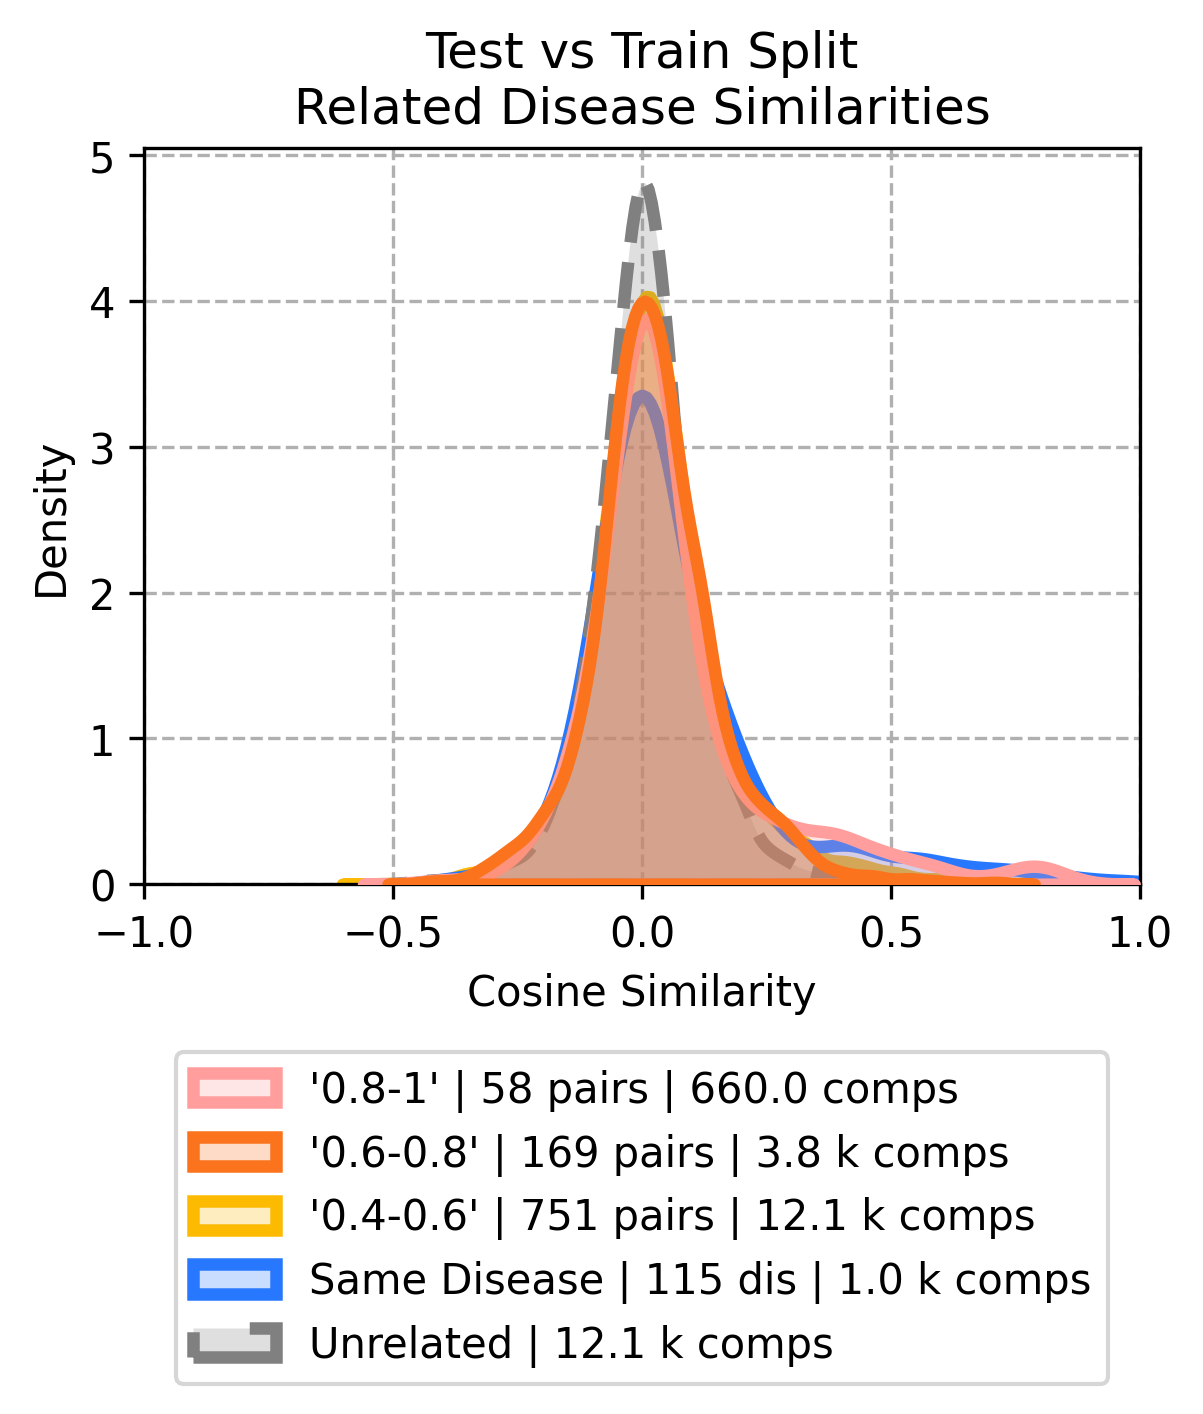

Nº of positive disease pairs: 660
Nº of positive disease pairs: 660
Nº of positive disease pairs: 3771
Nº of positive disease pairs: 3771
Nº of positive disease pairs: 12083
Nº of positive disease pairs: 10000
Nº of positive disease pairs: 1000
Nº of positive disease pairs: 1000


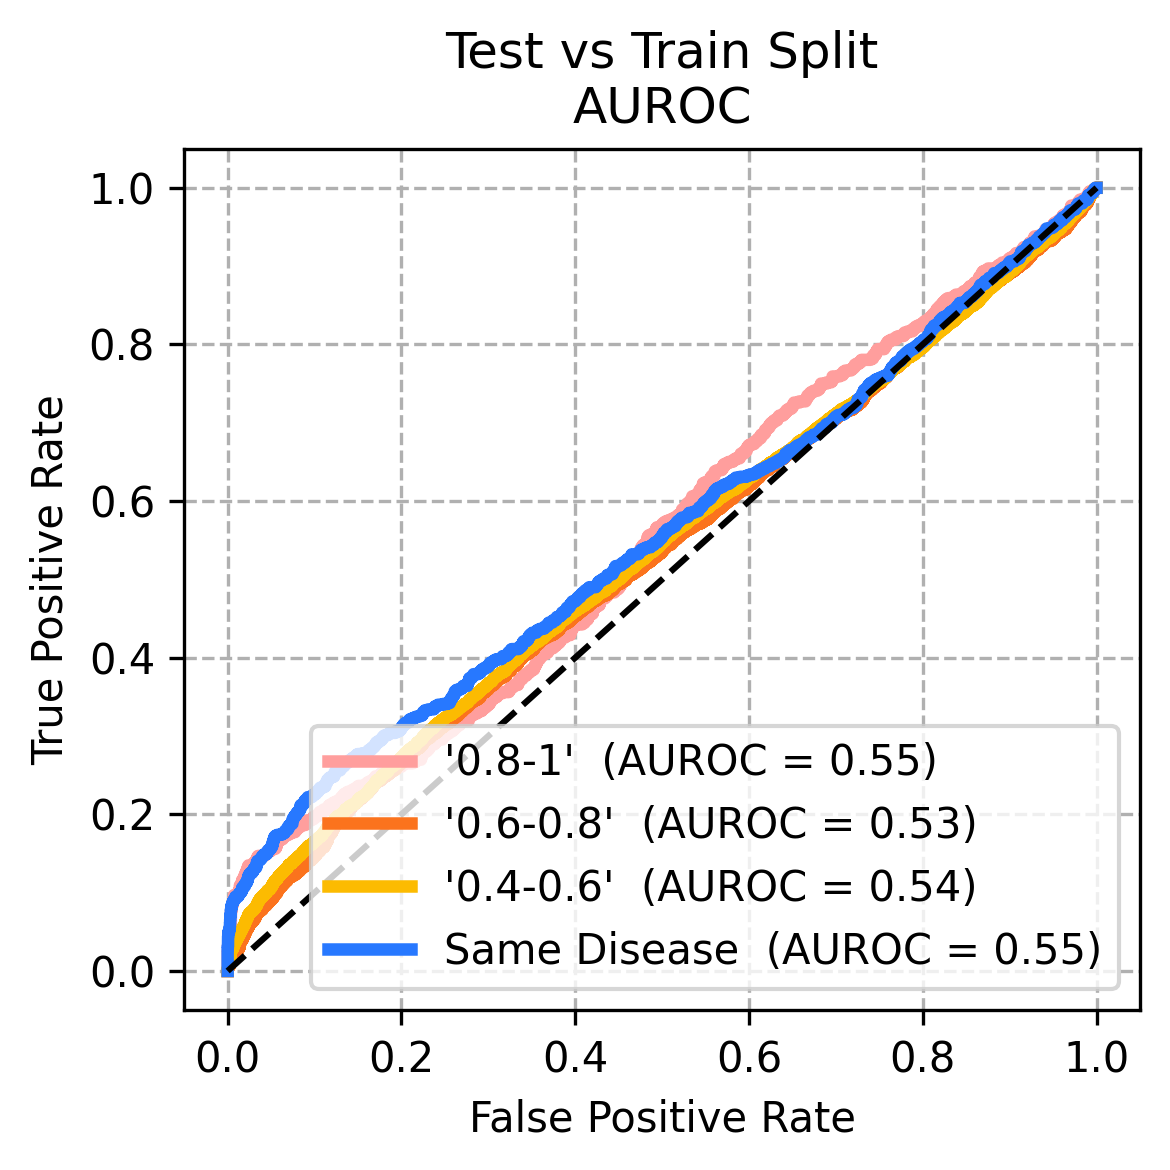

In [32]:
def get_bins(vals, bins):

    """
    Get the bin for each value in vals based on the provided bins.
    """
    bin_list = list()
    for val in vals:
        for i in range(len(bins) - 1):
            if bins[i] <= val < bins[i + 1]:
                bin_list.append((f"{bins[i]}-{bins[i + 1]}"))
                break
    return bin_list


# define related & unrelated groups
df_related = do_df_ic_query.copy()
df_unrelated = do_df_negative_ic.copy()

# convert to tuple for compatibility w/ unique
df_related["pair_sorted"] = df_related["pair_sorted"].apply(tuple)
df_unrelated["pair_sorted"] = df_unrelated["pair_sorted"].apply(tuple)

# bin data based on similarity
_bins = get_bins(do_df_ic_query["lin"].values,[0,0.2,0.4,0.6,0.8,1])
_bin_labels = ["'0.8-1'","'0.6-0.8'","'0.4-0.6'"]

# add new label to dataframe
df_related = df_related.copy()
df_related["shortest_path_length"] = _bins

# train
tr_s_all_1, tr_w_all_1, tr_l_all_1 = get_related_dis_sim(
    df_train, c_matrix_train, df_related, df_unrelated, labels=_bin_labels, sample=100000,
)

# test
ts_s_all_1, ts_w_all_1, ts_l_all_1 = get_related_dis_sim_splits(
    df_test, df_train, c_matrix_test_vs_train, df_related, df_unrelated, labels=_bin_labels, sample=1000)



# get unrelated pairs
tr_s_unr = vz.get_unrelated_pairs( df_train,do_df_ic_query,c_matrix_train,n_samples=10000,seed=42,)
ts_s_unr,_,_ =get_unrelated_pairs_split_2(df_test, df_train, c_matrix_test_vs_train, df_unrelated, dsaid_2_doid,sample_size=10000, include_control=True)

# plot
dpi_val = 300
colors_val=["#ff9e9d", "#fb731d", "#fcbb01","#2778ff","grey"]

# train
vz.plot_kde(tr_s_all_1, labels=tr_l_all_1, colors=colors_val, title="Train Split\nRelated Disease Similarities", metric="Cosine", weights=None, sample=10000, dpi=dpi_val, output_dir=None, x_lim_val=[-1,1])
vz.plot_roc(tr_s_all_1[:-1], tr_s_unr, labels=tr_l_all_1, title="Train Split\nAUROC", colors=colors_val, w_pos=tr_w_all_1,sample=10000,dpi=dpi_val, output_dir=None)

vz.plot_kde(ts_s_all_1, labels=ts_l_all_1, colors=colors_val, title="Test vs Train Split\nRelated Disease Similarities", metric="Cosine", weights=None, sample=10000, dpi=dpi_val, output_dir=None, x_lim_val=[-1,1])
vz.plot_roc(ts_s_all_1[:-1], ts_s_unr, labels=ts_l_all_1, title="Test vs Train Split\nAUROC", colors=colors_val, w_pos=None,sample=10000,dpi=dpi_val, output_dir=None)


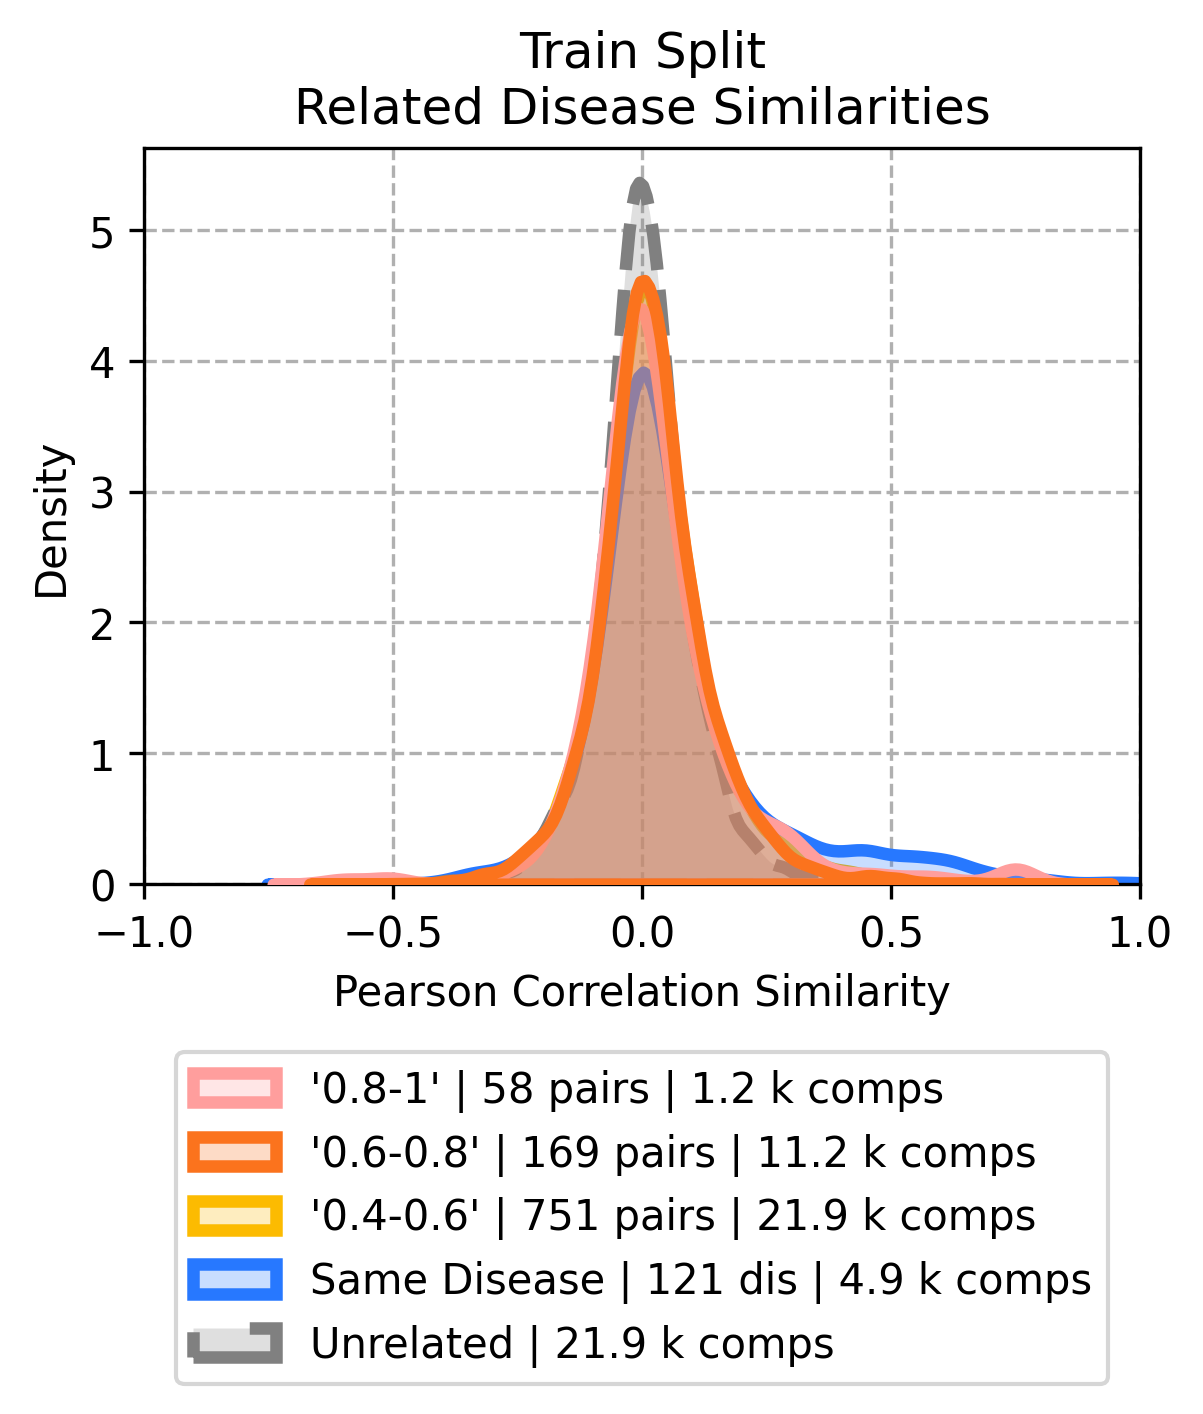

Nº of positive disease pairs: 1240
Nº of positive disease pairs: 1240
Nº of positive disease pairs: 11218
Nº of positive disease pairs: 10000
Nº of positive disease pairs: 21873
Nº of positive disease pairs: 10000
Nº of positive disease pairs: 4868
Nº of positive disease pairs: 4868


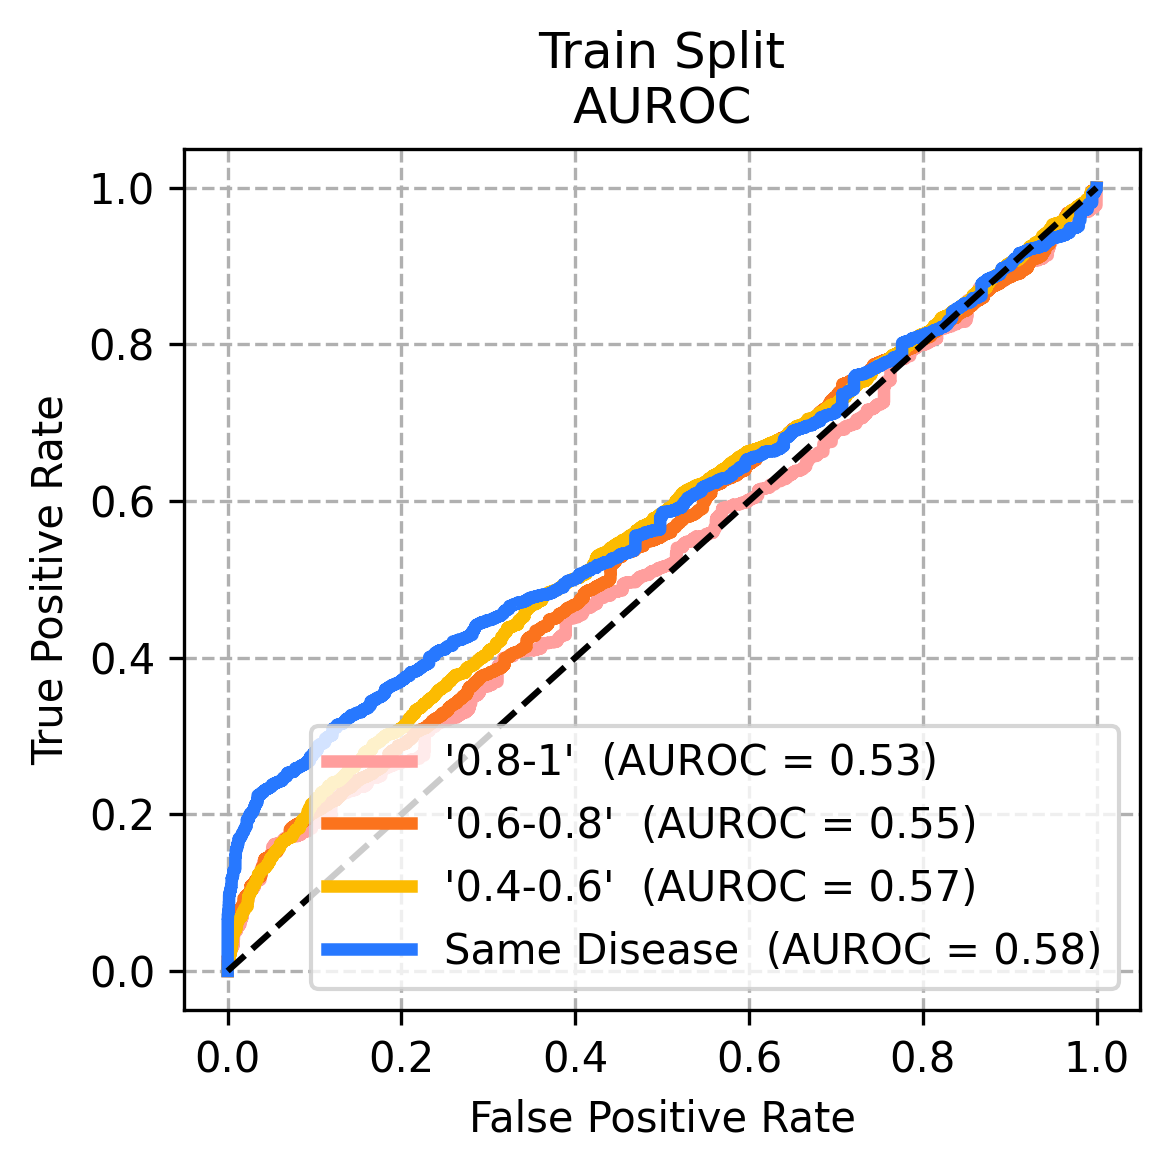

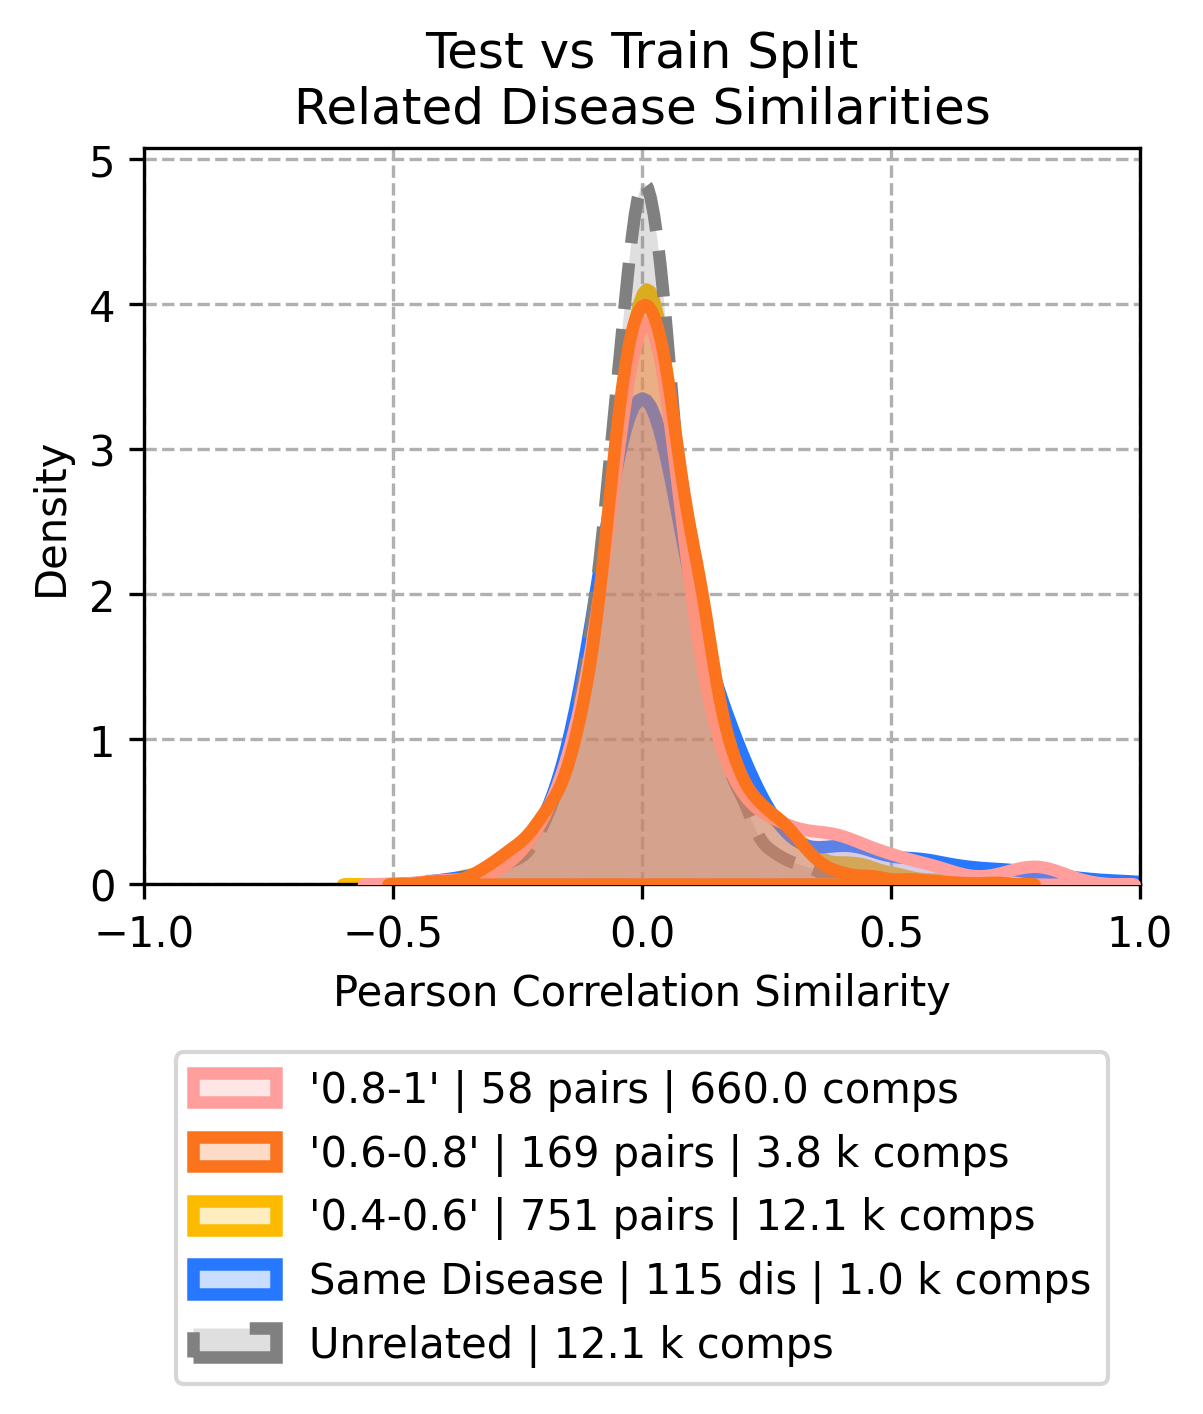

Nº of positive disease pairs: 660
Nº of positive disease pairs: 660
Nº of positive disease pairs: 3771
Nº of positive disease pairs: 3771
Nº of positive disease pairs: 12083
Nº of positive disease pairs: 10000
Nº of positive disease pairs: 1000
Nº of positive disease pairs: 1000


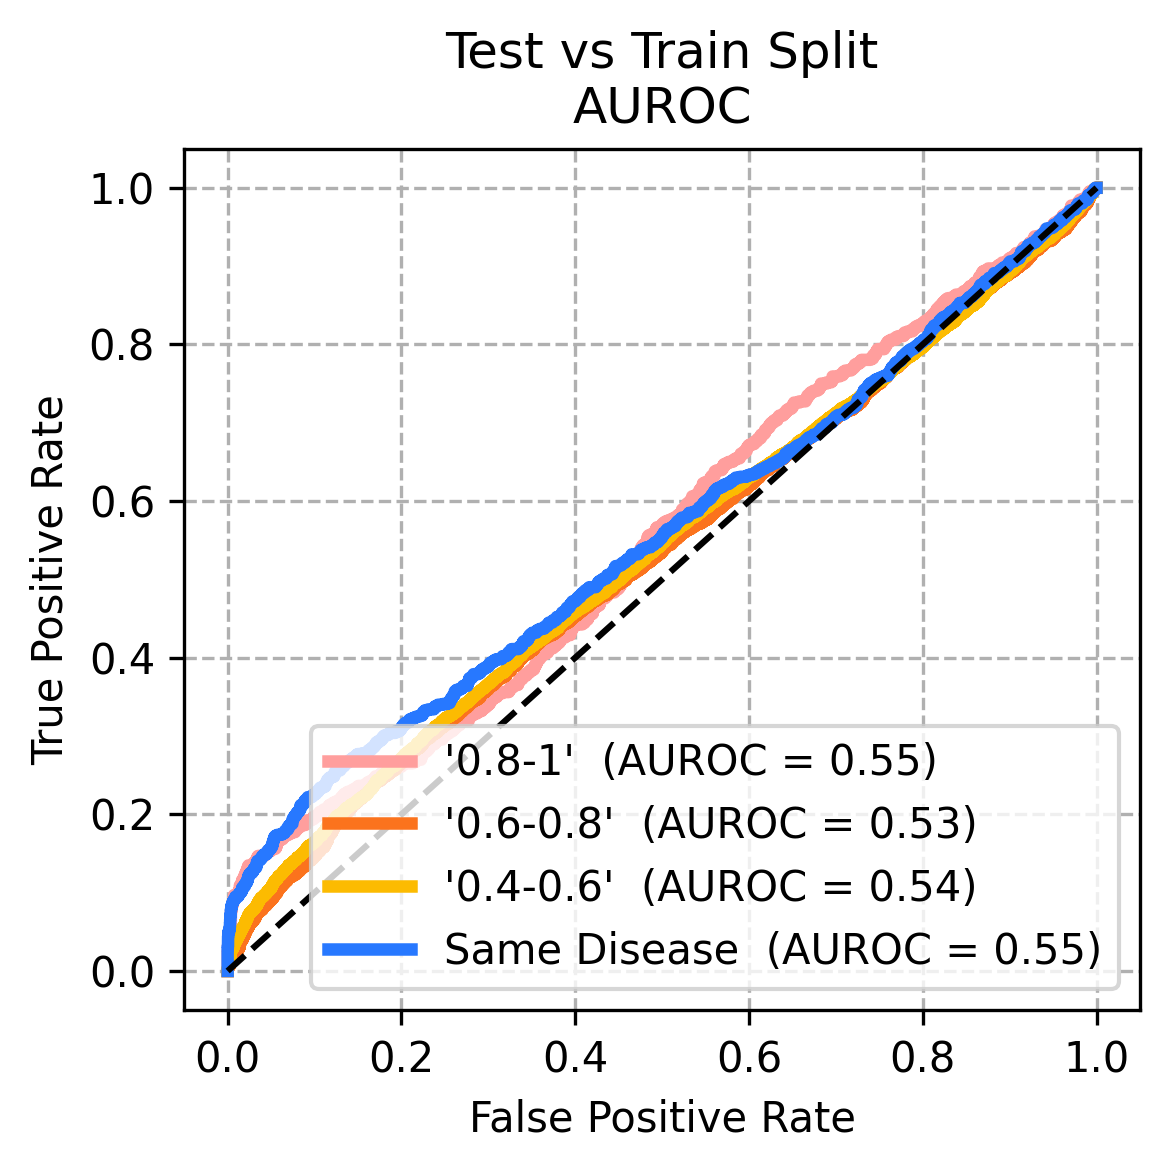

In [33]:
vz.plot_kde(tr_s_all_1, labels=tr_l_all_1, colors=colors_val, title="Train Split\nRelated Disease Similarities", metric="Pearson Correlation", weights=None, sample=10000, dpi=dpi_val, output_dir=None, x_lim_val=[-1,1])
vz.plot_roc(tr_s_all_1[:-1], tr_s_unr, labels=tr_l_all_1, title="Train Split\nAUROC", colors=colors_val, w_pos=tr_w_all_1,sample=10000,dpi=dpi_val, output_dir=None)

vz.plot_kde(ts_s_all_1, labels=ts_l_all_1, colors=colors_val, title="Test vs Train Split\nRelated Disease Similarities", metric="Pearson Correlation", weights=None, sample=10000, dpi=dpi_val, output_dir=None, x_lim_val=[-1,1])
vz.plot_roc(ts_s_all_1[:-1], ts_s_unr, labels=ts_l_all_1, title="Test vs Train Split\nAUROC", colors=colors_val, w_pos=None,sample=10000,dpi=dpi_val, output_dir=None)
